# Notebook 02 — Modélisation prédictive des ventes marketing

Ce notebook correspond à la suite logique du notebook d'EDA.

Objectif principal : entraîner plusieurs modèles de régression pour prédire les ventes (`sales`) à partir des budgets marketing (`tv`, `radio`, `social_media`) et du type d'influenceur (`influencer`).

Dans ce notebook, on va :
1. charger le dataset nettoyé ;
2. préparer les variables d'entrée et la cible ;
3. créer un pipeline de preprocessing ;
4. entraîner plusieurs modèles ;
5. comparer les performances ;
6. sélectionner le meilleur modèle ;
7. analyser les erreurs ;
8. interpréter les variables importantes ;
9. sauvegarder le modèle final pour le dashboard.

In [16]:
# À exécuter seulement si nécessaire
# !pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [17]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42

In [18]:
PROCESSED_PATH = Path("../data/processed/marketing_and_sales_cleaned.csv")
RAW_PATH = Path("../data/raw/Dummy Data HSS.csv")

if PROCESSED_PATH.exists():
    DATA_PATH = PROCESSED_PATH
    print("Chargement du dataset nettoyé :", DATA_PATH)
elif RAW_PATH.exists():
    DATA_PATH = RAW_PATH
    print("Dataset nettoyé introuvable. Chargement du dataset brut :", DATA_PATH)
else:
    raise FileNotFoundError(
        "Aucun fichier trouvé. Vérifie que le fichier existe dans ../data/processed/ ou ../data/raw/"
    )

df = pd.read_csv(DATA_PATH)

print("Dimensions du dataset :", df.shape)
display(df.head())

Chargement du dataset nettoyé : ..\data\processed\marketing_and_sales_cleaned.csv
Dimensions du dataset : (4546, 11)


,tv,radio,social_media,influencer,sales,total_budget,roi,tv_share,radio_share,social_media_share,sales_category
0,16.0,6.566231,2.907983,Mega,54.732757,25.474214,2.148555,0.628086,0.257760,0.114154,Low Performance
1,13.0,9.237765,2.409567,Mega,46.677897,24.647332,1.893832,0.527440,0.374798,0.097762,Low Performance
2,41.0,15.886446,2.913410,Mega,150.177829,59.799856,2.511341,0.685620,0.265660,0.048719,Medium Performance
3,83.0,30.020028,6.922304,Mega,298.246340,119.942332,2.486581,0.691999,0.250287,0.057714,High Performance
4,15.0,8.437408,1.405998,Micro,56.594181,24.843406,2.278036,0.603782,0.339624,0.056594,Low Performance


## Vérification et harmonisation des colonnes

Par sécurité, on remet les noms de colonnes au format standard utilisé dans le projet.

Cela évite les erreurs dues aux majuscules ou aux espaces dans les noms de colonnes.

In [19]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Colonnes disponibles :")
print(df.columns.tolist())

Colonnes disponibles :
['tv', 'radio', 'social_media', 'influencer', 'sales', 'total_budget', 'roi', 'tv_share', 'radio_share', 'social_media_share', 'sales_category']


## Nettoyage de sécurité avant modélisation

Même si le notebook d'EDA a déjà nettoyé les données, on refait ici un contrôle minimal.


In [20]:
required_columns = ["tv", "radio", "social_media", "influencer", "sales"]

missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    raise ValueError(f"Colonnes obligatoires manquantes : {missing_required}")

before_rows = len(df)

df = df.dropna(subset=required_columns).copy()

after_rows = len(df)

print(f"Lignes avant nettoyage : {before_rows}")
print(f"Lignes après nettoyage : {after_rows}")
print(f"Lignes supprimées : {before_rows - after_rows}")

display(df[required_columns].isna().sum())

Lignes avant nettoyage : 4546
Lignes après nettoyage : 4546
Lignes supprimées : 0


tv              0
radio           0
social_media    0
influencer      0
sales           0
dtype: int64

Création des variables métiers utiles

On calcule des variables utiles pour l'analyse métier et le dashboard :
- `total_budget` : budget total de la campagne ;
- `roi` : ventes divisées par budget total ;
- parts de budget par canal.



In [21]:
df["total_budget"] = df["tv"] + df["radio"] + df["social_media"]

df["roi"] = np.where(
    df["total_budget"] > 0,
    df["sales"] / df["total_budget"],
    np.nan
)

df["tv_share"] = df["tv"] / df["total_budget"]
df["radio_share"] = df["radio"] / df["total_budget"]
df["social_media_share"] = df["social_media"] / df["total_budget"]

display(df[[
    "tv",
    "radio",
    "social_media",
    "influencer",
    "total_budget",
    "sales",
    "roi"
]].head())

,tv,radio,social_media,influencer,total_budget,sales,roi
0,16.0,6.566231,2.907983,Mega,25.474214,54.732757,2.148555
1,13.0,9.237765,2.409567,Mega,24.647332,46.677897,1.893832
2,41.0,15.886446,2.913410,Mega,59.799856,150.177829,2.511341
3,83.0,30.020028,6.922304,Mega,119.942332,298.246340,2.486581
4,15.0,8.437408,1.405998,Micro,24.843406,56.594181,2.278036


## 7. Choix de la tâche prédictive

La tâche principale choisie est :

**Prédire les ventes (`sales`) à partir des budgets marketing et du type d'influenceur.**

C'est un problème de régression, car `sales` est une variable numérique continue.

Variables explicatives utilisées :
- `tv`
- `radio`
- `social_media`
- `influencer`

Variable cible :
- `sales`

In [22]:
target = "sales"

features = [
    "tv",
    "radio",
    "social_media",
    "influencer"
]

X = df[features].copy()
y = df[target].copy()

print("Variables explicatives :")
print(features)

print("\nVariable cible :")
print(target)

display(X.head())
display(y.head())

Variables explicatives :
['tv', 'radio', 'social_media', 'influencer']

Variable cible :
sales


,tv,radio,social_media,influencer
0,16.0,6.566231,2.907983,Mega
1,13.0,9.237765,2.409567,Mega
2,41.0,15.886446,2.913410,Mega
3,83.0,30.020028,6.922304,Mega
4,15.0,8.437408,1.405998,Micro


0     54.732757
1     46.677897
2    150.177829
3    298.246340
4     56.594181
Name: sales, dtype: float64

## Découpage train/test

On sépare les données en deux parties :
- `train` : utilisé pour entraîner les modèles ;
- `test` : utilisé uniquement pour évaluer les modèles.

On utilise 80 % des données pour l'entraînement et 20 % pour le test.

Comme `sales` est une variable continue, on crée des tranches de ventes pour conserver une répartition équilibrée entre train et test.

In [23]:
sales_bins = pd.qcut(
    y,
    q=5,
    labels=False,
    duplicates="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=sales_bins
)

print("Dimensions X_train :", X_train.shape)
print("Dimensions X_test :", X_test.shape)
print("Dimensions y_train :", y_train.shape)
print("Dimensions y_test :", y_test.shape)

Dimensions X_train : (3636, 4)
Dimensions X_test : (910, 4)
Dimensions y_train : (3636,)
Dimensions y_test : (910,)


## Vérification de la répartition train/test

On vérifie que les niveaux de ventes sont bien répartis entre le train et le test.


In [24]:
train_bins = pd.qcut(y_train, q=5, labels=["Très faible", "Faible", "Moyen", "Élevé", "Très élevé"], duplicates="drop")
test_bins = pd.qcut(y_test, q=5, labels=["Très faible", "Faible", "Moyen", "Élevé", "Très élevé"], duplicates="drop")

split_check = pd.DataFrame({
    "Train (%)": train_bins.value_counts(normalize=True).sort_index() * 100,
    "Test (%)": test_bins.value_counts(normalize=True).sort_index() * 100
})

display(split_check)

,Train (%),Test (%)
sales,,
Très faible,20.022002,20.0
Faible,19.994499,20.0
Moyen,19.994499,20.0
Élevé,19.994499,20.0
Très élevé,19.994499,20.0


## Création du pipeline de preprocessing

Le modèle ne peut pas utiliser directement la variable texte `influencer`.

On prépare donc les données avec :
- `StandardScaler` pour les variables numériques ;
- `OneHotEncoder` pour la variable catégorielle `influencer`.

L'intérêt du pipeline est d'éviter le data leakage : les transformations sont apprises uniquement sur le train set, puis appliquées au test set.

In [25]:
numeric_features = ["tv", "radio", "social_media"]
categorical_features = ["influencer"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="drop"
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## Définition des modèles

On définit plusieurs modèles pour respecter l'exigence de comparaison multi-modèles.

Modèles utilisés :
1. `DummyRegressor` : modèle naïf de référence ;
2. `LinearRegression` : baseline simple et interprétable ;
3. `Ridge` : régression linéaire régularisée ;
4. `RandomForestRegressor` : modèle non linéaire basé sur des arbres ;
5. `GradientBoostingRegressor` : modèle avancé basé sur du boosting ;
6. `MLPRegressor` : réseau de neurones multicouches.

Le MLP permet de couvrir la partie Deep Learning.

In [26]:
models = {
    "Dummy Regressor": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    "MLP Regressor": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=2000,
        early_stopping=True,
        random_state=RANDOM_STATE
    )
}

print("Nombre de modèles définis :", len(models))
print(list(models.keys()))

Nombre de modèles définis : 6
['Dummy Regressor', 'Linear Regression', 'Ridge Regression', 'Random Forest', 'Gradient Boosting', 'MLP Regressor']


## Fonction d'évaluation

On crée une fonction pour calculer les métriques de régression :

- `MAE` : erreur moyenne absolue ;
- `RMSE` : racine de l'erreur quadratique moyenne ;
- `R²` : part de variance expliquée par le modèle.

Plus le MAE et le RMSE sont faibles, meilleur est le modèle.
Plus le R² est proche de 1, meilleur est le modèle.

In [27]:
import time
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    

    start_time = time.time()

    # 1. Entraînement du modèle
    model.fit(X_train, y_train)

    # 2. Prédiction sur les données de test
    y_pred = model.predict(X_test)

    # 3. Calcul du temps d'entraînement
    training_time = time.time() - start_time

    # 4. Calcul des métriques
    mae = mean_absolute_error(y_test, y_pred)

    # Correction compatible avec toutes les versions de scikit-learn
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2 = r2_score(y_test, y_pred)

    # 5. Retourner les résultats
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "training_time_seconds": training_time,
        "predictions": y_pred,
        "fitted_model": model
    }

## Entraînement et évaluation des modèles

Chaque modèle est placé dans un pipeline complet :

`preprocessing + modèle`

Cela garantit que chaque modèle reçoit exactement les mêmes données préparées.

In [28]:
results = []
predictions = {}
fitted_models = {}

for model_name, estimator in models.items():
    print(f"Entraînement du modèle : {model_name}")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator)
        ]
    )

    result = evaluate_regression_model(
        model_name=model_name,
        model=pipeline,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test
    )

    results.append({
        "model": result["model"],
        "MAE": result["MAE"],
        "RMSE": result["RMSE"],
        "R2": result["R2"],
        "training_time_seconds": result["training_time_seconds"]
    })

    predictions[model_name] = result["predictions"]
    fitted_models[model_name] = result["fitted_model"]

results_df = pd.DataFrame(results).sort_values(by="RMSE", ascending=True)

display(results_df)

Entraînement du modèle : Dummy Regressor
Entraînement du modèle : Linear Regression
Entraînement du modèle : Ridge Regression
Entraînement du modèle : Random Forest
Entraînement du modèle : Gradient Boosting
Entraînement du modèle : MLP Regressor


,model,MAE,RMSE,R2,training_time_seconds
1,Linear Regression,2.364800,2.961060,9.989833e-01,0.006858
2,Ridge Regression,2.365742,2.962002,9.989827e-01,0.008855
4,Gradient Boosting,2.420943,3.025803,9.989384e-01,0.334189
3,Random Forest,2.721469,3.411255,9.986507e-01,0.432600
5,MLP Regressor,3.032489,4.046048,9.981018e-01,0.455931
0,Dummy Regressor,80.341632,92.865995,-8.311008e-07,0.008921


## Interprétation du tableau de résultats

Le tableau permet de comparer les modèles de manière quantitative.

Pour choisir le modèle final, on regarde principalement :
- un RMSE faible ;
- un MAE faible ;
- un R² élevé ;
- un temps d'entraînement raisonnable 


Les résultats obtenus montrent que les modèles testés parviennent globalement à prédire les ventes avec une très bonne précision. Le modèle le plus performant est la **régression linéaire**, avec une MAE de **2.36**, une RMSE de **2.96** et un coefficient de détermination R² de **0.99898**.

Cela signifie que le modèle commet en moyenne une erreur d’environ **2.36 millions** sur la prédiction des ventes. Le score R², très proche de 1, indique que le modèle explique presque toute la variabilité de la variable cible `sales`.

La **régression Ridge** obtient des résultats quasiment identiques à la régression linéaire. Cela montre que la régularisation n’apporte pas de gain significatif dans ce cas, probablement parce que les relations entre les variables explicatives et les ventes sont déjà très stables.

Les modèles plus complexes comme le **Gradient Boosting**, le **Random Forest** et le **MLP Regressor** obtiennent également de très bons scores, mais ils sont légèrement moins performants que les modèles linéaires. Le MLP Regressor permet de répondre à l’exigence du projet concernant l’intégration d’un modèle de Deep Learning, mais ses performances ne dépassent pas celles de la régression linéaire.

Le **Dummy Regressor** obtient une MAE et une RMSE très élevées, avec un R² proche de 0. Ce résultat est attendu, car ce modèle prédit simplement une valeur moyenne et ne tient pas compte des budgets marketing. Il sert donc uniquement de modèle de référence.

Ces résultats confirment les observations de l’EDA : les ventes semblent fortement liées aux budgets marketing, en particulier au budget TV. La relation étant très proche d’une relation linéaire, un modèle simple comme la régression linéaire est suffisant pour obtenir d’excellentes performances.

Dans ce contexte, le meilleur choix pour la prédiction des ventes est donc la **régression linéaire**, car elle offre le meilleur compromis entre performance, rapidité d’entraînement, simplicité et interprétabilité.



## Visualisation comparative des performances

On visualise les métriques pour comparer plus facilement les modèles.

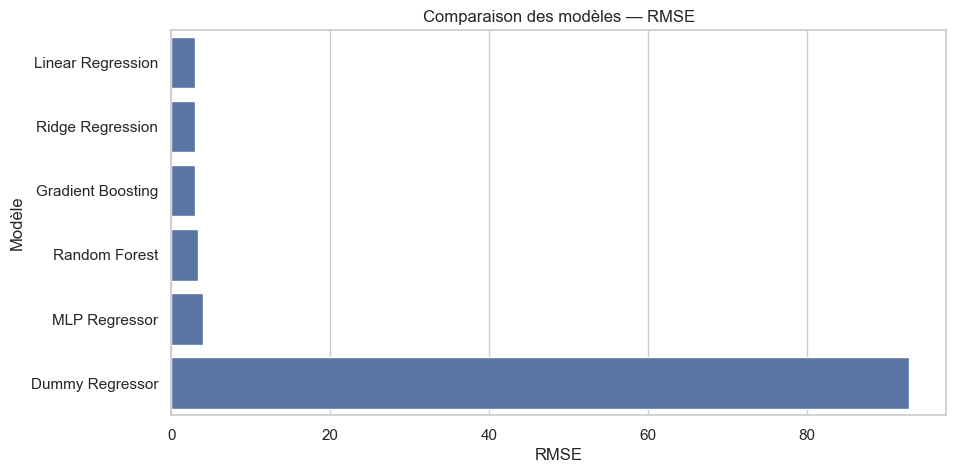

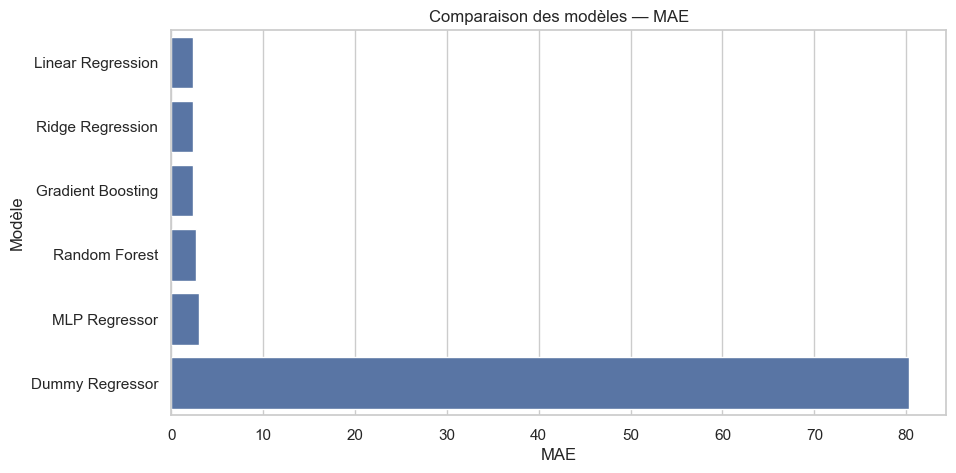

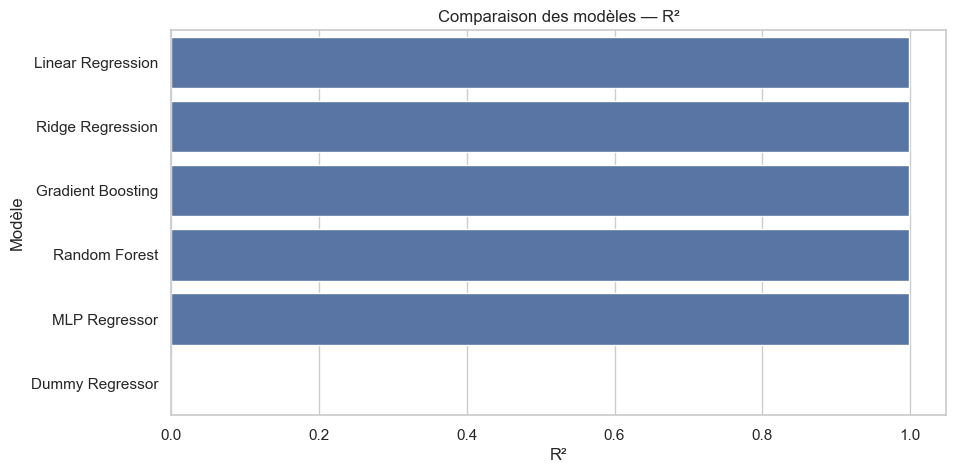

In [29]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="RMSE", y="model")
plt.title("Comparaison des modèles — RMSE")
plt.xlabel("RMSE")
plt.ylabel("Modèle")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="MAE", y="model")
plt.title("Comparaison des modèles — MAE")
plt.xlabel("MAE")
plt.ylabel("Modèle")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df.sort_values(by="R2", ascending=False), x="R2", y="model")
plt.title("Comparaison des modèles — R²")
plt.xlabel("R²")
plt.ylabel("Modèle")
plt.show()

## Interprétation des graphiques de comparaison des modèles — Prédiction des ventes

Les trois graphiques permettent de comparer les performances des modèles selon trois métriques : le **R²**, la **MAE** et la **RMSE**.

### Analyse du R²

Le graphique du R² montre que presque tous les modèles entraînés obtiennent un score très proche de **1**. Cela signifie que les modèles expliquent très bien la variation des ventes à partir des variables marketing utilisées : `tv`, `radio`, `social_media` et `influencer`.

La **régression linéaire**, la **régression Ridge**, le **Gradient Boosting**, le **Random Forest** et le **MLP Regressor** ont tous un R² très élevé. Cela confirme que la relation entre les budgets marketing et les ventes est très forte.

À l’inverse, le **Dummy Regressor** obtient un R² proche de 0. Ce résultat est normal, car ce modèle prédit simplement une valeur moyenne et ne tient pas compte des variables explicatives. Il sert uniquement de modèle de référence.

### Analyse de la MAE

La MAE mesure l’erreur moyenne absolue entre les ventes réelles et les ventes prédites. Plus la MAE est faible, meilleur est le modèle.

Le graphique montre que les modèles les plus performants sont :

1. **Linear Regression**
2. **Ridge Regression**
3. **Gradient Boosting**
4. **Random Forest**
5. **MLP Regressor**

La **régression linéaire** obtient la MAE la plus faible, environ **2.36**. Cela signifie qu’en moyenne, ses prédictions s’écartent des vraies ventes d’environ **2.36 millions**.

Le **Dummy Regressor** obtient une MAE beaucoup plus élevée, autour de **80**, ce qui montre qu’un modèle naïf est très insuffisant pour ce problème.

### Analyse de la RMSE

La RMSE mesure aussi l’erreur de prédiction, mais elle pénalise davantage les grosses erreurs. Plus la RMSE est faible, meilleur est le modèle.

Le graphique confirme les résultats observés avec la MAE : la **régression linéaire** est le modèle le plus performant, avec une RMSE d’environ **2.96**. La régression Ridge obtient un résultat quasiment identique.

Les modèles plus complexes comme le **Random Forest**, le **Gradient Boosting** et le **MLP Regressor** restent performants, mais ils ne font pas mieux que les modèles linéaires.

Cela indique que la relation entre les budgets marketing et les ventes est probablement très proche d’une relation linéaire. Dans ce cas, un modèle simple est plus adapté qu’un modèle complexe.

### Comparaison globale

Les résultats montrent que les modèles linéaires sont les meilleurs pour cette première problématique. La **Linear Regression** est le meilleur modèle, car elle combine :

- la plus faible MAE ;
- la plus faible RMSE ;
- le meilleur R² ;
- un temps d’entraînement très faible ;
- une interprétation simple des résultats.

Le **MLP Regressor**, qui correspond au modèle de Deep Learning, obtient de bons résultats mais reste moins performant que la régression linéaire. Cela montre que le Deep Learning n’est pas toujours nécessaire, surtout lorsque les relations entre les variables sont simples et linéaires.

### Limite des graphiques

Les graphiques de MAE et de RMSE sont fortement influencés par le **Dummy Regressor**, car ses erreurs sont beaucoup plus élevées que celles des autres modèles. À cause de cela, les différences entre les bons modèles sont visuellement moins visibles.

Pour mieux comparer les modèles performants, il serait utile d’ajouter un deuxième graphique sans le Dummy Regressor, afin de zoomer sur les différences entre Linear Regression, Ridge Regression, Gradient Boosting, Random Forest et MLP Regressor.

### Conclusion

Pour la prédiction des ventes, le modèle recommandé est la **Linear Regression**. Il obtient les meilleures performances tout en restant simple, rapide et facilement interprétable. Ce choix est cohérent avec les résultats de l’EDA, qui montraient déjà une forte relation entre les budgets marketing, en particulier le budget TV, et les ventes.

## Validation croisée

La validation croisée permet de vérifier que les performances ne dépendent pas uniquement d'un seul découpage train/test.

On utilise ici une validation croisée à 5 plis.

Pour chaque modèle, on calcule :
- le R² moyen ;
- le RMSE moyen ;
- l'écart-type du R².

In [30]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

for model_name, estimator in models.items():
    print(f"Validation croisée : {model_name}")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator)
        ]
    )

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring={
            "r2": "r2",
            "neg_rmse": "neg_root_mean_squared_error",
            "neg_mae": "neg_mean_absolute_error"
        },
        n_jobs=-1,
        return_train_score=False
    )

    cv_results.append({
        "model": model_name,
        "CV_R2_mean": scores["test_r2"].mean(),
        "CV_R2_std": scores["test_r2"].std(),
        "CV_RMSE_mean": -scores["test_neg_rmse"].mean(),
        "CV_MAE_mean": -scores["test_neg_mae"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV_RMSE_mean", ascending=True)

display(cv_results_df)

Validation croisée : Dummy Regressor
Validation croisée : Linear Regression
Validation croisée : Ridge Regression
Validation croisée : Random Forest
Validation croisée : Gradient Boosting
Validation croisée : MLP Regressor


,model,CV_R2_mean,CV_R2_std,CV_RMSE_mean,CV_MAE_mean
1,Linear Regression,0.998991,0.000035,2.952068,2.366858
2,Ridge Regression,0.998991,0.000036,2.952413,2.367246
4,Gradient Boosting,0.998960,0.000037,2.996972,2.397140
3,Random Forest,0.998709,0.000046,3.339625,2.669463
5,MLP Regressor,0.998211,0.000218,3.927738,2.953418
0,Dummy Regressor,-0.000913,0.000604,93.013477,80.590455


## Interprétation de la validation croisée — Prédiction des ventes

La validation croisée permet de vérifier si les performances des modèles sont stables sur plusieurs découpages du jeu de données. Contrairement à un simple train/test split, elle évalue les modèles sur plusieurs sous-échantillons, ce qui donne une vision plus fiable de leur capacité à généraliser.

Les résultats confirment que la **Linear Regression** est le meilleur modèle pour la prédiction des ventes. Elle obtient un score moyen de **R² = 0.998991**, une **RMSE moyenne de 2.95** et une **MAE moyenne de 2.37**. Ces valeurs sont quasiment identiques à celles obtenues sur le jeu de test, ce qui montre que le modèle est stable et ne dépend pas d’un découpage favorable des données.

La **Ridge Regression** obtient des performances presque identiques à la régression linéaire. Cela signifie que l’ajout d’une régularisation n’apporte pas de gain significatif dans ce cas. La relation entre les variables explicatives et les ventes semble suffisamment simple et stable pour être bien capturée par un modèle linéaire classique.

Le **Gradient Boosting** obtient également de très bons résultats, avec un R² moyen de **0.998960**, mais sa RMSE et sa MAE sont légèrement supérieures à celles des modèles linéaires. Il reste donc performant, mais il n’améliore pas la prédiction par rapport à une régression linéaire.

Le **Random Forest** et le **MLP Regressor** obtiennent aussi des scores élevés, mais ils sont moins performants que les modèles linéaires. Le MLP Regressor, qui correspond au modèle de Deep Learning, respecte l’exigence du projet, mais il ne surpasse pas les modèles plus simples. Cela montre que le Deep Learning n’est pas nécessairement le meilleur choix lorsque les relations dans les données sont principalement linéaires.

Le **Dummy Regressor** obtient un R² moyen négatif et des erreurs très élevées, avec une RMSE moyenne d’environ **93.01** et une MAE moyenne d’environ **80.59**. Cela confirme qu’un modèle naïf, qui prédit simplement une valeur moyenne, est largement insuffisant pour cette problématique.

Un point important est la valeur très faible de l’écart-type du R² pour les meilleurs modèles. Par exemple, la Linear Regression a un écart-type de seulement **0.000035**. Cela signifie que ses performances varient très peu d’un fold à l’autre. Le modèle est donc non seulement performant, mais aussi très stable.

En conclusion, la validation croisée confirme que la **Linear Regression** est le modèle final le plus pertinent pour la prédiction des ventes. Elle offre le meilleur compromis entre performance, stabilité, rapidité d’entraînement, simplicité et interprétabilité.

## Sélection du modèle final


In [31]:
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_predictions = predictions[best_model_name]

print("Meilleur modèle selon le RMSE :", best_model_name)

best_metrics = results_df[results_df["model"] == best_model_name]
display(best_metrics)

Meilleur modèle selon le RMSE : Linear Regression


,model,MAE,RMSE,R2,training_time_seconds
1,Linear Regression,2.3648,2.96106,0.998983,0.006858


## Analyse des prédictions du meilleur modèle

On compare les valeurs réelles et les valeurs prédites.

Si les points sont proches de la diagonale, le modèle prédit correctement les ventes.

,y_true,y_pred,residual,absolute_error
2206,245.518027,245.595894,-0.077866,0.077866
3139,210.230046,210.095854,0.134192,0.134192
2900,33.459886,35.513976,-2.054091,2.054091
2849,259.900723,263.438152,-3.537429,3.537429
191,357.124573,356.142170,0.982403,0.982403


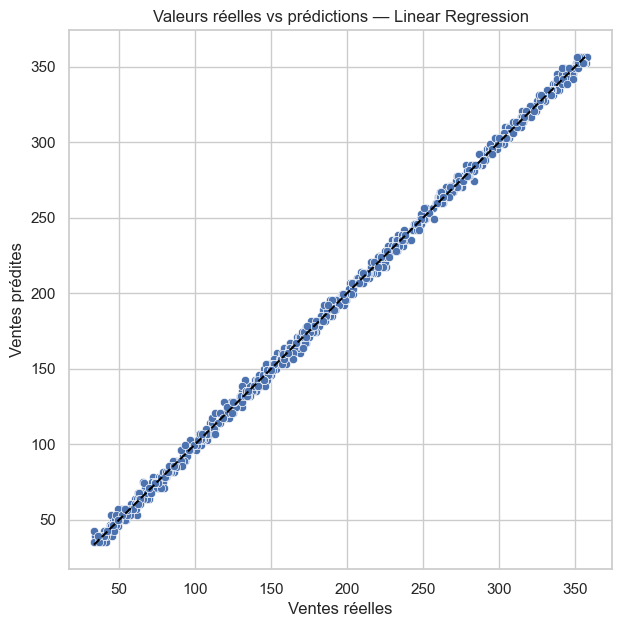

In [32]:
comparison_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": best_predictions
})

comparison_df["residual"] = comparison_df["y_true"] - comparison_df["y_pred"]
comparison_df["absolute_error"] = comparison_df["residual"].abs()

display(comparison_df.head())

plt.figure(figsize=(7, 7))
sns.scatterplot(data=comparison_df, x="y_true", y="y_pred")
min_value = min(comparison_df["y_true"].min(), comparison_df["y_pred"].min())
max_value = max(comparison_df["y_true"].max(), comparison_df["y_pred"].max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--", color="black")
plt.title(f"Valeurs réelles vs prédictions — {best_model_name}")
plt.xlabel("Ventes réelles")
plt.ylabel("Ventes prédites")
plt.show()

## Analyse des erreurs — Linear Regression

Le graphique compare les **ventes réelles** avec les **ventes prédites** par le modèle de régression linéaire.

Chaque point représente une campagne marketing du jeu de test.  
L’axe horizontal correspond aux ventes réelles, tandis que l’axe vertical correspond aux ventes prédites par le modèle.

On observe que les points sont presque parfaitement alignés sur la diagonale. Cela signifie que les prédictions du modèle sont très proches des vraies valeurs. Plus les points sont proches de cette diagonale, plus le modèle est précis.

Ce résultat confirme les très bonnes performances obtenues précédemment avec les métriques :

- MAE faible ;
- RMSE faible ;
- R² très proche de 1.

Le modèle arrive donc à prédire correctement les ventes sur des campagnes qu’il n’a pas vues pendant l’entraînement.

### Analyse des résidus

Le tableau présente quelques exemples de prédictions avec :

- `y_true` : la valeur réelle des ventes ;
- `y_pred` : la valeur prédite par le modèle ;
- `residual` : l’écart entre la valeur réelle et la valeur prédite ;
- `absolute_error` : l’erreur absolue, c’est-à-dire l’écart sans tenir compte du signe.

Par exemple, pour certaines lignes, l’erreur est très faible :

- une vente réelle de **245.52** est prédite à **245.60**, avec une erreur absolue de seulement **0.08** ;
- une vente réelle de **210.23** est prédite à **210.10**, avec une erreur absolue de seulement **0.13**.

Cela montre que le modèle est capable de produire des prédictions très précises.

D’autres lignes présentent des erreurs un peu plus importantes, par exemple :

- une vente réelle de **259.90** est prédite à **263.44**, soit une erreur absolue d’environ **3.54** ;
- une vente réelle de **33.46** est prédite à **35.51**, soit une erreur absolue d’environ **2.05**.

Ces erreurs restent faibles par rapport à l’échelle globale des ventes, qui varie environ entre 30 et 360.

### Interprétation du signe du résidu

Le résidu permet de savoir si le modèle surestime ou sous-estime les ventes :

- si le résidu est positif, le modèle a sous-estimé la vente réelle ;
- si le résidu est négatif, le modèle a surestimé la vente réelle.

Par exemple :

- pour la ligne où `y_true = 259.90` et `y_pred = 263.44`, le résidu est négatif : le modèle a légèrement surestimé les ventes ;
- pour la ligne où `y_true = 357.12` et `y_pred = 356.14`, le résidu est positif : le modèle a légèrement sous-estimé les ventes.

### Conclusion

L’analyse des erreurs confirme que la **Linear Regression** est un modèle très performant pour la prédiction des ventes. Les prédictions sont proches des valeurs réelles, les résidus sont faibles, et aucune erreur extrême ne ressort dans les exemples affichés.

Ce comportement est cohérent avec l’EDA : les ventes sont fortement liées aux budgets marketing, en particulier au budget TV. La relation étant très linéaire, un modèle simple comme la régression linéaire est suffisant pour obtenir d’excellentes performances.

Le modèle peut donc être retenu comme modèle final pour la première problématique : **prédiction des ventes à partir d’un scénario budgétaire marketing**.

## 19. Analyse des erreurs

Les résidus correspondent à :

`résidu = valeur réelle - valeur prédite`

Cette analyse permet de voir si le modèle fait des erreurs importantes sur certains types de campagnes.

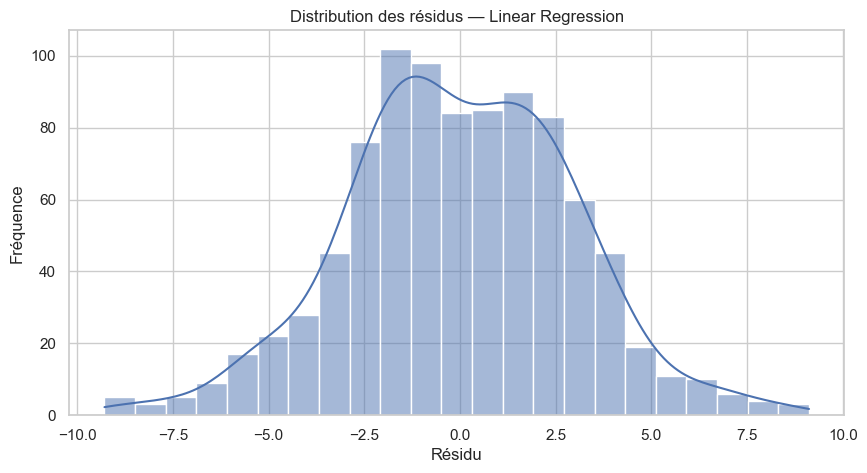

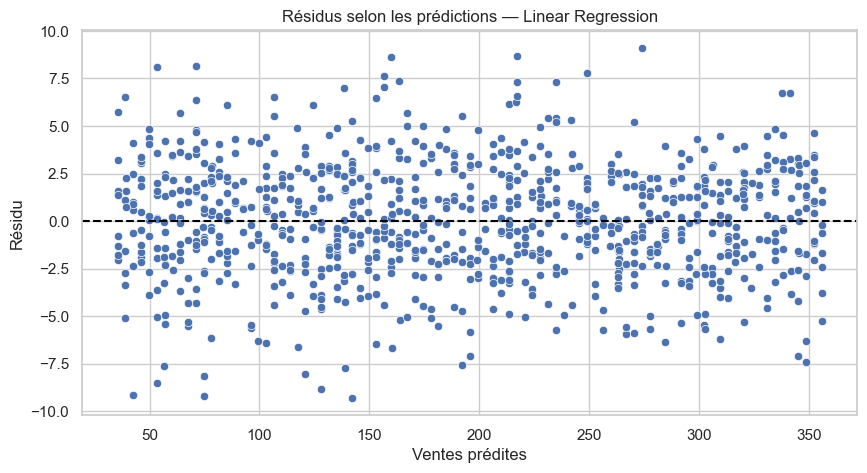

Top 10 des plus grandes erreurs absolues :


,y_true,y_pred,residual,absolute_error
4162,133.021187,142.308261,-9.287074,9.287074
2262,65.534254,74.724724,-9.190470,9.190470
505,33.509810,42.647282,-9.137473,9.137473
2085,283.251107,274.134692,9.116415,9.116415
4426,119.220715,128.070090,-8.849376,8.849376
4451,225.822151,217.117873,8.704278,8.704278
3468,168.675296,160.054207,8.621089,8.621089
3450,44.761717,53.276322,-8.514604,8.514604
2545,66.496644,74.651874,-8.155230,8.155230
3523,79.281709,71.131905,8.149803,8.149803


In [33]:
plt.figure(figsize=(10, 5))
sns.histplot(comparison_df["residual"], kde=True)
plt.title(f"Distribution des résidus — {best_model_name}")
plt.xlabel("Résidu")
plt.ylabel("Fréquence")
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=comparison_df, x="y_pred", y="residual")
plt.axhline(0, linestyle="--", color="black")
plt.title(f"Résidus selon les prédictions — {best_model_name}")
plt.xlabel("Ventes prédites")
plt.ylabel("Résidu")
plt.show()

print("Top 10 des plus grandes erreurs absolues :")
display(comparison_df.sort_values(by="absolute_error", ascending=False).head(10))

## Analyse des résidus — Linear Regression

Après avoir sélectionné la **Linear Regression** comme meilleur modèle pour la prédiction des ventes, nous analysons maintenant ses erreurs de prédiction à travers les résidus.

Un résidu correspond à la différence entre la valeur réelle et la valeur prédite :

`résidu = vente réelle - vente prédite`

Si le résidu est proche de 0, cela signifie que la prédiction est très proche de la réalité.

### Distribution des résidus

Le premier graphique présente la distribution des résidus du modèle.

On observe que les résidus sont globalement centrés autour de **0**. Cela signifie que le modèle ne semble pas avoir de biais majeur : il ne surestime pas systématiquement les ventes et ne les sous-estime pas systématiquement.

La majorité des erreurs se situe approximativement entre **-5 et +5**, ce qui reste faible par rapport à l’échelle des ventes, qui varie environ entre 30 et 360. Quelques erreurs plus importantes apparaissent autour de **-9** et **+9**, mais elles restent limitées.

La forme globale de la distribution est relativement équilibrée, même si elle n’est pas parfaitement normale. Cela reste acceptable dans ce contexte, car les erreurs sont faibles et centrées autour de zéro.

### Résidus selon les prédictions

Le second graphique montre les résidus en fonction des ventes prédites.

Les points sont répartis de manière assez aléatoire autour de la ligne horizontale située à 0. Cela est un bon signe : cela signifie que le modèle ne présente pas de tendance claire à faire plus d’erreurs pour les faibles ventes ou pour les fortes ventes.

On ne voit pas de forme particulière, comme une courbe ou un cône très marqué. Cela indique que la relation linéaire utilisée par le modèle est adaptée aux données.

Cependant, on observe tout de même quelques erreurs plus importantes, avec des résidus proches de **-9** ou **+9**. Ces erreurs restent rares et ne remettent pas en cause la performance globale du modèle.

### Analyse du top 10 des plus grandes erreurs

Le tableau affiche les 10 campagnes pour lesquelles le modèle fait les plus grandes erreurs absolues.

La plus grande erreur est d’environ **9.29 millions** :

- vente réelle : **133.02**
- vente prédite : **142.31**
- résidu : **-9.29**

Cela signifie que le modèle a surestimé les ventes d’environ **9.29 millions** pour cette campagne.

On retrouve aussi des erreurs similaires :

- vente réelle de **65.53** prédite à **74.72**, soit une surestimation d’environ **9.19** ;
- vente réelle de **283.25** prédite à **274.13**, soit une sous-estimation d’environ **9.12** ;
- vente réelle de **225.82** prédite à **217.12**, soit une sous-estimation d’environ **8.70**.

Même les plus grandes erreurs restent relativement faibles par rapport à l’échelle globale des ventes. Cela confirme que le modèle est robuste.

### Interprétation métier

D’un point de vue métier, ces erreurs signifient que le modèle peut fournir une estimation fiable des ventes attendues à partir d’un scénario budgétaire marketing.

Pour un responsable marketing, une erreur moyenne faible et des résidus bien répartis sont des éléments positifs. Le modèle peut donc être utilisé comme outil d’aide à la décision pour anticiper les ventes selon les budgets investis en TV, Radio, Social Media et selon le type d’influenceur.

Les quelques erreurs plus élevées peuvent venir de facteurs que le dataset ne contient pas, par exemple :

- la qualité réelle de la campagne ;
- la période de diffusion ;
- la saisonnalité ;
- la notoriété de la marque ;
- le contenu publicitaire ;
- le public ciblé ;
- la concurrence.

Ces variables absentes peuvent expliquer pourquoi certaines campagnes sont légèrement moins bien prédites.

### Conclusion

L’analyse des résidus confirme que la **Linear Regression** est adaptée à la prédiction des ventes. Les erreurs sont faibles, globalement centrées autour de 0 et réparties de manière aléatoire.

Le modèle ne montre pas de biais évident et ses plus grandes erreurs restent limitées. Ces résultats renforcent le choix de la **Linear Regression** comme modèle final pour la première problématique : **prédire les ventes à partir des budgets marketing et du type d’influenceur**.

## 21. Importance des variables par permutation importance

La permutation importance mesure l'importance d'une variable en observant la perte de performance lorsque cette variable est mélangée.

Si mélanger une variable fait fortement baisser la performance, alors cette variable est importante pour le modèle.

,feature,importance_mean,importance_std
0,tv,128.605050,2.793048
1,radio,0.001550,0.001243
3,influencer,0.000942,0.001000
2,social_media,-0.004012,0.001555


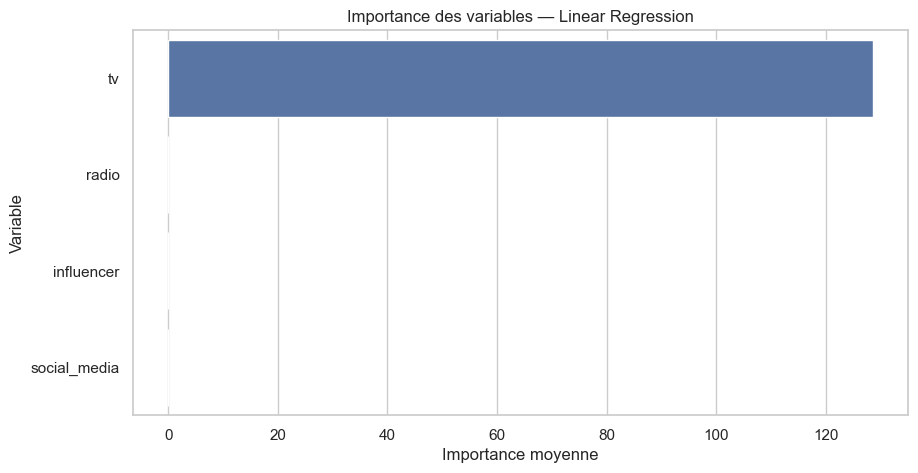

In [34]:
perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": features,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(by="importance_mean", ascending=False)

display(importance_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x="importance_mean", y="feature")
plt.title(f"Importance des variables — {best_model_name}")
plt.xlabel("Importance moyenne")
plt.ylabel("Variable")
plt.show()

## Interprétation de l'importance des variables

Cette analyse permet de répondre à une question métier :

**Quels leviers marketing influencent le plus les ventes ?**

On s'attend à retrouver une importance forte pour `tv`, car l'EDA a montré une corrélation très élevée entre le budget TV et les ventes.


L’analyse de l’importance des variables permet de comprendre quelles variables influencent le plus les prédictions du modèle.

Dans notre cas, le modèle final retenu pour la prédiction des ventes est la **Linear Regression**. L’objectif est donc d’identifier quelles variables marketing expliquent le plus les ventes prédites.

### Variable la plus importante : `tv`

Le graphique montre très clairement que la variable **`tv`** est de loin la variable la plus importante.

Son importance moyenne est très élevée :

- `tv` : **128.61**

Cela signifie que lorsque l’on perturbe ou modifie la variable `tv`, la performance du modèle se dégrade fortement. Autrement dit, le modèle dépend beaucoup du budget TV pour prédire les ventes.

Cette conclusion est cohérente avec l’EDA réalisée précédemment, où nous avions déjà observé une très forte corrélation entre le budget TV et les ventes.

D’un point de vue métier, cela signifie que le budget TV semble être le principal levier explicatif des ventes dans ce dataset.

### Variables moins importantes : `radio`, `influencer` et `social_media`

Les autres variables ont une importance très faible par rapport à `tv` :

- `radio` : **0.0015**
- `influencer` : **0.0009**
- `social_media` : **-0.0040**

Cela ne signifie pas forcément que ces variables sont inutiles dans la réalité métier. Cela signifie surtout que, dans ce dataset et pour ce modèle, elles apportent très peu d’information supplémentaire par rapport au budget TV.

La variable `radio` a une importance légèrement positive, mais son impact reste très faible.  
La variable `influencer` a également une importance très faible, ce qui indique que le type d’influenceur influence peu les prédictions du modèle de ventes.  
La variable `social_media` présente une importance légèrement négative. Cela peut arriver avec la permutation importance lorsque la variable n’aide pas réellement le modèle ou lorsque son effet est très faible par rapport aux autres variables.

### Interprétation métier

Ces résultats indiquent que le modèle prédit principalement les ventes à partir du budget TV.

Cela peut s’expliquer par le fait que les ventes sont presque linéairement liées à cette variable dans le dataset. Le modèle de régression linéaire apprend donc principalement cette relation.

Pour un responsable marketing, cette analyse suggère que :

- le budget TV est le canal le plus déterminant dans la prédiction des ventes ;
- les budgets Radio et Social Media ont un effet plus faible dans ce modèle ;
- le type d’influenceur n’améliore pas fortement la prédiction des ventes ;
- la performance commerciale semble surtout dépendre du niveau d’investissement TV.

### Limite de l’interprétation

Il faut rester prudent : cette analyse montre une relation prédictive, pas une causalité certaine.

Dire que `tv` est la variable la plus importante signifie que le modèle l’utilise fortement pour prédire les ventes. Cela ne prouve pas automatiquement que la TV cause directement l’augmentation des ventes dans un contexte réel.

De plus, certaines variables peuvent être corrélées entre elles. Par exemple, les campagnes avec un fort budget TV peuvent aussi avoir des budgets Radio ou Social Media plus élevés. Dans ce cas, le modèle peut attribuer une grande partie de l’explication à `tv`, même si d’autres canaux participent aussi à la performance globale.

### Conclusion

L’importance des variables confirme que la **variable `tv` est le principal facteur explicatif des ventes** dans ce modèle.

Cette conclusion renforce le choix de la **Linear Regression** : le modèle est performant, simple et facilement interprétable. Il permet d’expliquer clairement pourquoi certaines campagnes génèrent plus de ventes : elles sont principalement associées à un budget TV plus élevé.

Pour la suite du projet, cette information sera utile dans le dashboard afin d’expliquer à l’utilisateur métier quels canaux marketing influencent le plus les prédictions.

## 23. Test d'un scénario marketing

On crée un exemple de scénario pour simuler une prédiction.

Ce type de fonction sera ensuite réutilisé dans le dashboard Streamlit.

In [35]:
def predict_sales_scenario(tv, radio, social_media, influencer):
    scenario = pd.DataFrame({
        "tv": [tv],
        "radio": [radio],
        "social_media": [social_media],
        "influencer": [influencer]
    })

    predicted_sales = best_model.predict(scenario)[0]
    total_budget = tv + radio + social_media

    estimated_roi = predicted_sales / total_budget if total_budget > 0 else np.nan

    return {
        "predicted_sales": predicted_sales,
        "total_budget": total_budget,
        "estimated_roi": estimated_roi
    }

scenario_result = predict_sales_scenario(
    tv=80,
    radio=25,
    social_media=5,
    influencer="Macro"
)

scenario_result

{'predicted_sales': np.float64(284.8513911384174),
 'total_budget': 110,
 'estimated_roi': np.float64(2.58955810125834)}

## Test d'un scénario budgétaire avec le modèle final

Après avoir sélectionné la **Linear Regression** comme modèle final pour la prédiction des ventes, nous avons testé un scénario budgétaire simulé.

Pour ce scénario, le budget total est de **110 millions**. Le modèle prédit des ventes d’environ **284.85 millions**.

À partir de cette prédiction, nous calculons également un ROI estimé :

`ROI estimé = ventes prédites / budget total`

Le ROI obtenu est d’environ **2.59**. Cela signifie que, selon le modèle, chaque million investi dans cette configuration budgétaire pourrait générer environ **2.59 millions de ventes**.

Ce test montre que le modèle peut être utilisé comme un outil d’aide à la décision. Un responsable marketing peut modifier les budgets TV, Radio, Social Media et le type d’influenceur afin d’obtenir une estimation des ventes attendues et du ROI associé.

Le modèle final a ensuite été sauvegardé dans le dossier `models` sous le nom :

`best_sales_model.joblib`

Les résultats d’évaluation ont également été sauvegardés dans le dossier `reports`. Ces fichiers pourront être réutilisés dans la suite du projet, notamment pour construire le dashboard interactif.

## Sauvegarde des résultats et du modèle final

On sauvegarde :
- le meilleur modèle ;
- le nom du meilleur modèle ;
- les métriques ;
- les prédictions ;
- l'importance des variables.

Ces fichiers seront utiles pour le dashboard et pour le rapport.

In [36]:
MODELS_DIR = Path("../models")
REPORTS_DIR = Path("../reports")
FIGURES_DIR = REPORTS_DIR / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, MODELS_DIR / "best_sales_model.joblib")

with open(MODELS_DIR / "best_model_name.txt", "w", encoding="utf-8") as f:
    f.write(best_model_name)

results_df.to_csv(REPORTS_DIR / "model_comparison_test_results.csv", index=False)
cv_results_df.to_csv(REPORTS_DIR / "model_comparison_cv_results.csv", index=False)
comparison_df.to_csv(REPORTS_DIR / "best_model_predictions.csv", index=False)
importance_df.to_csv(REPORTS_DIR / "permutation_importance.csv", index=False)

print("Modèle final sauvegardé :", MODELS_DIR / "best_sales_model.joblib")
print("Résultats sauvegardés dans :", REPORTS_DIR)

Modèle final sauvegardé : ..\models\best_sales_model.joblib
Résultats sauvegardés dans : ..\reports


## Conclusion de la modélisation

Cette première phase de modélisation avait pour objectif de prédire les ventes (`sales`) à partir des budgets marketing (`tv`, `radio`, `social_media`) et du type d’influenceur (`influencer`). Il s’agit d’une tâche de régression, car la variable cible est une valeur numérique continue.

Plusieurs modèles ont été entraînés et comparés afin de respecter une démarche multi-modèles :

- Dummy Regressor ;
- Linear Regression ;
- Ridge Regression ;
- Random Forest Regressor ;
- Gradient Boosting Regressor ;
- MLP Regressor.

Le **Dummy Regressor** a servi de modèle de référence. Ses performances sont très faibles, avec une erreur élevée et un R² proche de 0. Cela confirme qu’un modèle naïf, qui prédit simplement la moyenne des ventes, n’est pas adapté à cette problématique.

Les autres modèles obtiennent tous de très bonnes performances. Cependant, la **Linear Regression** est le modèle le plus performant selon la RMSE. Elle obtient une **MAE de 2.36**, une **RMSE de 2.96** et un **R² de 0.99898**. Ces résultats indiquent que le modèle prédit les ventes avec une très faible erreur et explique presque toute la variabilité de la variable cible.

La validation croisée confirme également la stabilité du modèle. La Linear Regression conserve un R² moyen très élevé et des erreurs moyennes faibles sur plusieurs découpages du jeu de données. Cela montre que ses performances ne dépendent pas uniquement d’un split train/test favorable.

L’analyse des erreurs montre que les prédictions sont très proches des valeurs réelles. Les résidus sont globalement centrés autour de 0, ce qui indique que le modèle ne surestime pas ou ne sous-estime pas systématiquement les ventes. Les plus grandes erreurs restent limitées par rapport à l’échelle globale des ventes.

L’analyse de l’importance des variables montre que le budget **TV** est de loin la variable la plus déterminante dans la prédiction des ventes. Les variables `radio`, `social_media` et `influencer` ont une importance plus faible dans ce modèle. Cette conclusion est cohérente avec l’EDA, qui montrait déjà une très forte relation entre le budget TV et les ventes.

Même si des modèles plus complexes comme le Random Forest, le Gradient Boosting ou le MLP Regressor ont été testés, ils ne surpassent pas la régression linéaire. Cela montre que, dans ce dataset, la relation entre les budgets marketing et les ventes est principalement linéaire. Le Deep Learning n’apporte donc pas de gain réel pour cette première problématique.

Le modèle final retenu pour la prédiction des ventes est donc la **Linear Regression**, car il offre le meilleur compromis entre performance, stabilité, rapidité, simplicité et interprétabilité.

Ce modèle a ensuite été sauvegardé dans le dossier `models` sous le nom `best_sales_model.joblib`. Il pourra être réutilisé dans le dashboard afin de permettre à un utilisateur métier de saisir un scénario budgétaire et d’obtenir une prédiction des ventes ainsi qu’une estimation du ROI associé.